# Parameter Estimation with `difflow.estimation`

This notebook demonstrates the `difflow.estimation` module — a structured API for
parameter estimation inspired by pyomo's `parmest`, powered by JAX autodiff.

## What You'll Learn

1. **Experiment objects** — packaging experimental data
2. **Estimator.fit()** — fitting parameters with exact gradients
3. **Confidence intervals** — Fisher information CIs via `jax.hessian`
4. **Diagnostics** — R², RMSE, AIC/BIC, residual analysis
5. **Summary reports** — one-line result tables

## Why Use `difflow.estimation`?

Compared to manual parameter estimation (see notebook 14), this module:
- Encapsulates the boilerplate (loss functions, scipy calls, CI computation)
- Provides JAX-compiled objectives with exact gradients automatically
- Offers a consistent `Experiment` data structure
- Includes diagnostics (R², AIC, BIC) and formatted summaries

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

from difflow.estimation import Estimator, Experiment

print("Setup complete")

W0000 00:00:1771937372.124257 20956375 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1771937372.130865 20956375 service.cc:145] XLA service 0x822c80b00 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771937372.131022 20956375 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1771937372.131992 20956375 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1771937372.132015 20956375 mps_client.cc:384] XLA backend will use up to 55662313472 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


Setup complete


## 1. A Simple Linear Model

Start with the simplest case: fitting a line $y = a x + b$ to noisy data.

### Step 1: Define the model function

The model function must follow this convention:
```python
def model_fn(theta_dict, experiment) -> dict[str, float]
```
- `theta_dict`: parameter names → values (e.g., `{'a': 2.0, 'b': 1.0}`)
- `experiment`: an `Experiment` object (read inputs from `experiment.inputs`)
- Returns: predictions dict with keys matching `experiment.observed`

In [2]:
def linear_model(theta, exp):
    """y = a * x + b"""
    return {'y': theta['a'] * exp.inputs['x'] + theta['b']}

### Step 2: Create Experiment objects

Each `Experiment` holds the inputs, observed outputs, and optional uncertainties.

In [3]:
# True parameters (unknown to the estimator)
a_true, b_true = 2.5, 0.8

# Generate noisy data
rng = np.random.default_rng(42)
x_data = np.linspace(0.5, 5.0, 12)
noise_std = 0.3

experiments = []
for x in x_data:
    y = a_true * x + b_true + noise_std * rng.standard_normal()
    experiments.append(Experiment(
        inputs={'x': float(x)},
        observed={'y': float(y)},
    ))

print(f"Created {len(experiments)} experiments")
print(f"First experiment: {experiments[0]}")
print(f"Output names: {experiments[0].output_names}")

Created 12 experiments
First experiment: Experiment(inputs={'x': 0.5}, observed={'y': 2.141415123926329}, uncertainties=None, name='', metadata={})
Output names: ['y']


### Step 3: Create an Estimator and fit

In [4]:
est = Estimator(linear_model, param_names=['a', 'b'])

result = est.fit(experiments, theta_init={'a': 1.0, 'b': 0.0})

print(f"Converged: {result.converged}")
print(f"Estimated a = {result.theta_opt['a']:.4f} (true: {a_true})")
print(f"Estimated b = {result.theta_opt['b']:.4f} (true: {b_true})")
print(f"Objective (SSE) = {result.objective_value:.6f}")

Converged: True
Estimated a = 2.5328 (true: 2.5)
Estimated b = 0.6673 (true: 0.8)
Objective (SSE) = 0.883816


### Step 4: Confidence intervals and diagnostics

In [5]:
ci = est.confidence_intervals(result, experiments)

print("95% Confidence Intervals:")
for name in ['a', 'b']:
    print(f"  {name}: [{ci.ci_lower[name]:.4f}, {ci.ci_upper[name]:.4f}]  "
          f"(std err = {ci.std_errors[name]:.4f})")

# Check if true values fall within CIs
for name, true_val in [('a', a_true), ('b', b_true)]:
    in_ci = ci.ci_lower[name] <= true_val <= ci.ci_upper[name]
    print(f"  True {name}={true_val} within CI: {in_ci}")

95% Confidence Intervals:
  a: [2.4371, 2.6286]  (std err = 0.0430)
  b: [0.3713, 0.9633]  (std err = 0.1328)
  True a=2.5 within CI: True
  True b=0.8 within CI: True


In [6]:
# Full summary report
print(est.summary(result, experiments))

Parameter Estimation Summary
Converged: True
Objective value: 0.883816
Iterations: 5

Parameters:
  Name                   Value      Std Err     CI Lower     CI Upper
  ---------------------------------------------------------------
  a                    2.53282    0.0429713      2.43708      2.62857
  b                   0.667271     0.132842     0.371281     0.963261

Diagnostics:
  R-squared:     0.994276
  Adj R-squared: 0.993004
  RMSE:          0.271388
  AIC:           -27.3010
  BIC:           -26.3311
  N obs:         12
  N params:      2


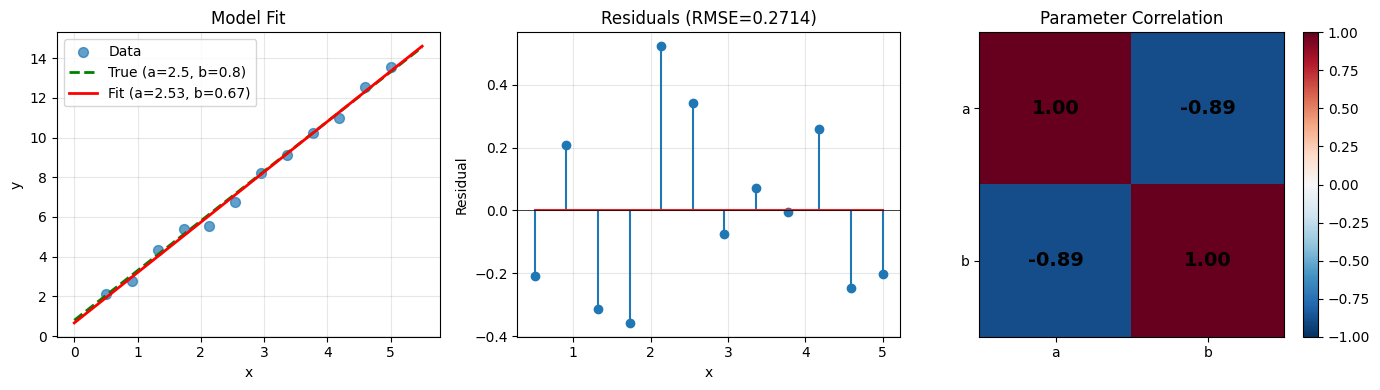

In [7]:
# Visualize the fit
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Data and fit
x_plot = np.linspace(0, 5.5, 100)
y_true = a_true * x_plot + b_true
y_est = result.theta_opt['a'] * x_plot + result.theta_opt['b']

axes[0].scatter([exp.inputs['x'] for exp in experiments],
                [exp.observed['y'] for exp in experiments],
                label='Data', alpha=0.7, s=50)
axes[0].plot(x_plot, y_true, 'g--', label=f'True (a={a_true}, b={b_true})', lw=2)
axes[0].plot(x_plot, y_est, 'r-', label=f'Fit (a={result.theta_opt["a"]:.2f}, b={result.theta_opt["b"]:.2f})', lw=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Model Fit')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
diag = est.diagnostics(result, experiments)
residuals = [r['y'] for r in diag.residuals]
axes[1].stem([exp.inputs['x'] for exp in experiments], residuals)
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residual')
axes[1].set_title(f'Residuals (RMSE={diag.rmse:.4f})')
axes[1].grid(True, alpha=0.3)

# Correlation matrix
im = axes[2].imshow(ci.correlation, cmap='RdBu_r', vmin=-1, vmax=1)
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['a', 'b'])
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['a', 'b'])
axes[2].set_title('Parameter Correlation')
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f'{float(ci.correlation[i, j]):.2f}',
                     ha='center', va='center', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()

## 2. Nonlinear Model: Exponential Decay

Fit $y = A \cdot \exp(-k \cdot t)$ — a common kinetic model.

The JAX-powered Hessian gives exact second derivatives for confidence intervals,
even for nonlinear models.

In [8]:
def decay_model(theta, exp):
    """y = A * exp(-k * t)"""
    return {'y': theta['A'] * jnp.exp(-theta['k'] * exp.inputs['t'])}

# True parameters
A_true, k_true = 5.0, 0.3

# Generate data
rng = np.random.default_rng(123)
t_data = np.linspace(0.0, 10.0, 20)
decay_experiments = []
for t in t_data:
    y = A_true * np.exp(-k_true * t) + 0.15 * rng.standard_normal()
    decay_experiments.append(Experiment(
        inputs={'t': float(t)},
        observed={'y': float(y)},
    ))

# Fit
est_decay = Estimator(
    decay_model,
    param_names=['A', 'k'],
    param_bounds={'A': (0.1, 20.0), 'k': (0.01, 5.0)},
)
result_decay = est_decay.fit(decay_experiments, theta_init={'A': 3.0, 'k': 0.1})

print(est_decay.summary(result_decay, decay_experiments))

Parameter Estimation Summary
Converged: True
Objective value: 0.284552
Iterations: 15

Parameters:
  Name                   Value      Std Err     CI Lower     CI Upper
  ---------------------------------------------------------------
  A                    4.96811    0.0609444      4.84007      5.09615
  k                   0.293621   0.00563929     0.281774     0.305469

Diagnostics:
  R-squared:     0.992554
  Adj R-squared: 0.991678
  RMSE:          0.119279
  AIC:           -81.0515
  BIC:           -79.0600
  N obs:         20
  N params:      2


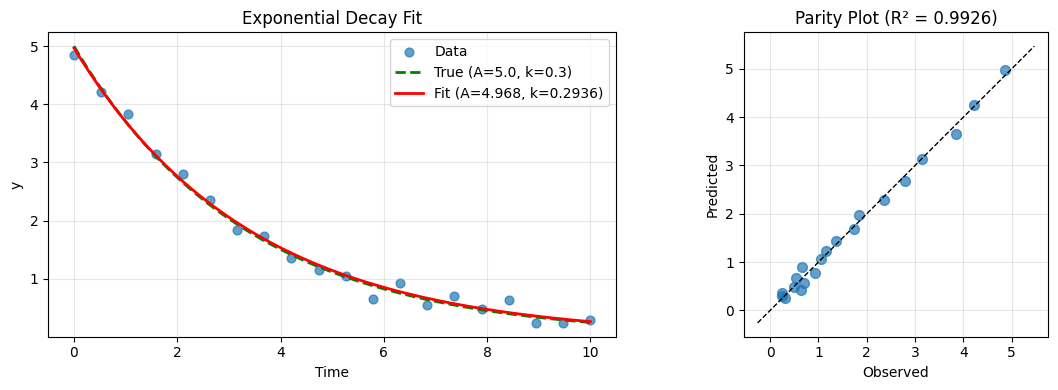

In [9]:
# Plot fit and confidence band
ci_decay = est_decay.confidence_intervals(result_decay, decay_experiments)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

t_plot = np.linspace(0, 10, 200)
y_fit = result_decay.theta_opt['A'] * np.exp(-result_decay.theta_opt['k'] * t_plot)
y_true_plot = A_true * np.exp(-k_true * t_plot)

axes[0].scatter([e.inputs['t'] for e in decay_experiments],
                [e.observed['y'] for e in decay_experiments],
                label='Data', alpha=0.7, s=40)
axes[0].plot(t_plot, y_true_plot, 'g--', label=f'True (A={A_true}, k={k_true})', lw=2)
axes[0].plot(t_plot, y_fit, 'r-', lw=2,
             label=f'Fit (A={result_decay.theta_opt["A"]:.3f}, k={result_decay.theta_opt["k"]:.4f})')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('y')
axes[0].set_title('Exponential Decay Fit')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Parity plot
diag_decay = est_decay.diagnostics(result_decay, decay_experiments)
observed = [e.observed['y'] for e in decay_experiments]
predicted = [e.observed['y'] + r['y'] for e, r in zip(decay_experiments, diag_decay.residuals)]
# Actually: predicted = observed + residual, so predicted = observed + (pred - obs) = pred
# Let's compute correctly
predicted = []
for e in decay_experiments:
    p = decay_model(result_decay.theta_opt, e)
    predicted.append(float(p['y']))

axes[1].scatter(observed, predicted, s=50, alpha=0.7)
lims = [min(min(observed), min(predicted)) - 0.5, max(max(observed), max(predicted)) + 0.5]
axes[1].plot(lims, lims, 'k--', lw=1)
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Parity Plot (R² = {diag_decay.r_squared:.4f})')
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Multi-Output Estimation

Estimate parameters from models that predict multiple outputs simultaneously.
Here we fit a Michaelis-Menten model: $v = V_{max} \cdot S / (K_m + S)$
and predict both the rate and the substrate consumption.

In [10]:
def mm_model(theta, exp):
    """Michaelis-Menten kinetics with two outputs."""
    S = exp.inputs['S']
    v = theta['Vmax'] * S / (theta['Km'] + S)
    # After time dt, substrate consumed
    dt = exp.inputs['dt']
    S_final = S - v * dt
    return {'rate': v, 'S_final': S_final}

# True parameters
Vmax_true, Km_true = 10.0, 2.0

# Generate data at different substrate concentrations
rng = np.random.default_rng(7)
dt = 0.1
mm_experiments = []
for S in [0.5, 1.0, 2.0, 3.0, 5.0, 8.0, 12.0, 20.0]:
    v_true = Vmax_true * S / (Km_true + S)
    S_final_true = S - v_true * dt
    mm_experiments.append(Experiment(
        inputs={'S': float(S), 'dt': dt},
        observed={
            'rate': float(v_true + 0.3 * rng.standard_normal()),
            'S_final': float(S_final_true + 0.05 * rng.standard_normal()),
        },
    ))

est_mm = Estimator(mm_model, param_names=['Vmax', 'Km'],
                    param_bounds={'Vmax': (0.1, 100.0), 'Km': (0.01, 50.0)})
result_mm = est_mm.fit(mm_experiments, {'Vmax': 5.0, 'Km': 1.0})

print(est_mm.summary(result_mm, mm_experiments))

Parameter Estimation Summary
Converged: True
Objective value: 0.0666396
Iterations: 11

Parameters:
  Name                   Value      Std Err     CI Lower     CI Upper
  ---------------------------------------------------------------
  Vmax                 10.0908    0.0483005       9.9872      10.1944
  Km                   2.08909    0.0344407      2.01522      2.16295

Diagnostics:
  R-squared:     0.999806
  Adj R-squared: 0.999776
  RMSE:          0.0645366
  AIC:           -83.6967
  BIC:           -82.1515
  N obs:         16
  N params:      2


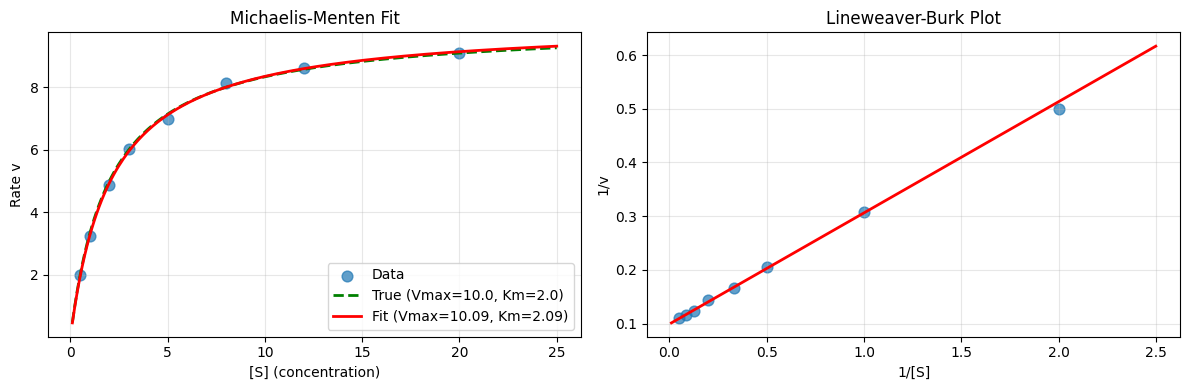

In [11]:
# Visualize Michaelis-Menten fit
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

S_plot = np.linspace(0.1, 25, 200)
v_true_plot = Vmax_true * S_plot / (Km_true + S_plot)
v_fit_plot = result_mm.theta_opt['Vmax'] * S_plot / (result_mm.theta_opt['Km'] + S_plot)

axes[0].scatter([e.inputs['S'] for e in mm_experiments],
                [e.observed['rate'] for e in mm_experiments],
                label='Data', s=60, alpha=0.7)
axes[0].plot(S_plot, v_true_plot, 'g--', lw=2, label=f'True (Vmax={Vmax_true}, Km={Km_true})')
axes[0].plot(S_plot, v_fit_plot, 'r-', lw=2,
             label=f'Fit (Vmax={result_mm.theta_opt["Vmax"]:.2f}, Km={result_mm.theta_opt["Km"]:.2f})')
axes[0].set_xlabel('[S] (concentration)')
axes[0].set_ylabel('Rate v')
axes[0].set_title('Michaelis-Menten Fit')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Lineweaver-Burk plot (1/v vs 1/S)
S_data = np.array([e.inputs['S'] for e in mm_experiments])
v_data = np.array([e.observed['rate'] for e in mm_experiments])
axes[1].scatter(1/S_data, 1/v_data, s=60, alpha=0.7)
S_inv = np.linspace(0.01, 1/0.4, 100)
v_inv_fit = (result_mm.theta_opt['Km'] / result_mm.theta_opt['Vmax']) * S_inv + 1/result_mm.theta_opt['Vmax']
axes[1].plot(S_inv, v_inv_fit, 'r-', lw=2)
axes[1].set_xlabel('1/[S]')
axes[1].set_ylabel('1/v')
axes[1].set_title('Lineweaver-Burk Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Weighted Least Squares

When measurements have different uncertainties, use weighted SSE.
Experiments with smaller uncertainties get more weight in the fit.

In [12]:
# Create experiments with varying measurement uncertainty
rng = np.random.default_rng(99)
weighted_experiments = []

for x in np.linspace(0.5, 5.0, 10):
    # Uncertainty grows with x (e.g., harder to measure at extremes)
    sigma = 0.1 + 0.15 * x
    y = a_true * x + b_true + sigma * rng.standard_normal()
    weighted_experiments.append(Experiment(
        inputs={'x': float(x)},
        observed={'y': float(y)},
        uncertainties={'y': float(sigma)},
    ))

# Compare SSE vs WSSE
est_w = Estimator(linear_model, ['a', 'b'])
result_sse = est_w.fit(weighted_experiments, {'a': 1.0, 'b': 0.0}, objective='sse')
result_wsse = est_w.fit(weighted_experiments, {'a': 1.0, 'b': 0.0}, objective='wsse')

print(f"{'':>15} {'a':>10} {'b':>10}")
print(f"{'True':>15} {a_true:>10.4f} {b_true:>10.4f}")
print(f"{'SSE fit':>15} {result_sse.theta_opt['a']:>10.4f} {result_sse.theta_opt['b']:>10.4f}")
print(f"{'WSSE fit':>15} {result_wsse.theta_opt['a']:>10.4f} {result_wsse.theta_opt['b']:>10.4f}")
print()
print("WSSE gives more weight to precise measurements (low x),")
print("often recovering the true parameters more accurately.")

                         a          b
           True     2.5000     0.8000
        SSE fit     2.5005     0.7545
       WSSE fit     2.4827     0.7992

WSSE gives more weight to precise measurements (low x),
often recovering the true parameters more accurately.


## 5. CSTR Kinetic Parameter Estimation

Now let's use the estimation module with a difflow CSTR model.
We estimate the rate constant `k` from outlet concentration data at different flow rates.

In [13]:
from difflow import CSTR, CSTRParams, make_stream

# Rate function: A -> B, r = k * C_A
def rate_fn(C, T, params):
    return jnp.array([params['k'] * C['A']])

stoich = jnp.array([[-1.0], [+1.0]])

# True rate constant
k_true_cstr = 0.15

# Generate synthetic CSTR data at different flow rates
rng = np.random.default_rng(0)
flow_rates = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
cstr_experiments = []

for F_A_in in flow_rates:
    cstr = CSTR(
        CSTRParams(V=1.0, rate_fn=rate_fn, stoich=stoich,
                   rate_params={'k': k_true_cstr}, species_order=['A', 'B']),
        mode='isothermal',
    )
    inlet = make_stream({'A': F_A_in, 'B': 0.0}, T=350.0, P=101325.0)
    outlet, _ = cstr(inlet, T_spec=350.0)

    # Add measurement noise
    F_A_out_noisy = float(outlet['F_A']) + 0.01 * rng.standard_normal()
    cstr_experiments.append(Experiment(
        inputs={'F_A_in': F_A_in},
        observed={'F_A_out': F_A_out_noisy},
        name=f'F_A_in={F_A_in}',
    ))

print(f"Created {len(cstr_experiments)} CSTR experiments")
for e in cstr_experiments:
    print(f"  F_A_in={e.inputs['F_A_in']:.1f}  F_A_out={e.observed['F_A_out']:.4f}")

Created 8 CSTR experiments
  F_A_in=0.5  F_A_out=0.0325
  F_A_in=1.0  F_A_out=0.1163
  F_A_in=1.5  F_A_out=0.2564
  F_A_in=2.0  F_A_out=0.4221
  F_A_in=2.5  F_A_out=0.6196
  F_A_in=3.0  F_A_out=0.8608
  F_A_in=4.0  F_A_out=1.4043
  F_A_in=5.0  F_A_out=2.0095


In [14]:
# Model function that wraps the CSTR
def cstr_model(theta, exp):
    """Predict outlet flow from CSTR."""
    cstr = CSTR(
        CSTRParams(V=1.0, rate_fn=rate_fn, stoich=stoich,
                   rate_params={'k': theta['k']}, species_order=['A', 'B']),
        mode='isothermal',
    )
    inlet = make_stream({'A': exp.inputs['F_A_in'], 'B': 0.0}, T=350.0, P=101325.0)
    outlet, _ = cstr(inlet, T_spec=350.0)
    return {'F_A_out': outlet['F_A']}

# Fit
est_cstr = Estimator(cstr_model, ['k'], param_bounds={'k': (0.001, 10.0)})
result_cstr = est_cstr.fit(cstr_experiments, theta_init={'k': 0.05})

print(est_cstr.summary(result_cstr, cstr_experiments))

Parameter Estimation Summary
Converged: True
Objective value: 0.000148748
Iterations: 5

Parameters:
  Name                   Value      Std Err     CI Lower     CI Upper
  ---------------------------------------------------------------
  k                   0.148792  0.000278216     0.148134      0.14945

Diagnostics:
  R-squared:     0.999955
  Adj R-squared: 0.999947
  RMSE:          0.00431202
  AIC:           -85.1416
  BIC:           -85.0621
  N obs:         8
  N params:      1


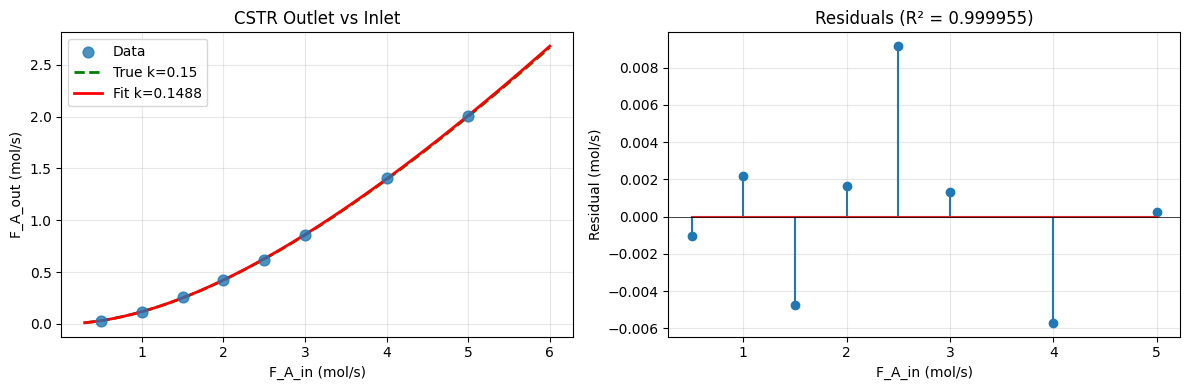

In [15]:
# Visualize CSTR fit
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Outlet flow vs inlet flow
F_in_plot = np.linspace(0.3, 6.0, 50)
F_out_true = []
F_out_fit = []
for F in F_in_plot:
    for k_val, out_list in [(k_true_cstr, F_out_true), (result_cstr.theta_opt['k'], F_out_fit)]:
        cstr = CSTR(
            CSTRParams(V=1.0, rate_fn=rate_fn, stoich=stoich,
                       rate_params={'k': k_val}, species_order=['A', 'B']),
            mode='isothermal',
        )
        inlet = make_stream({'A': float(F), 'B': 0.0}, T=350.0, P=101325.0)
        outlet, _ = cstr(inlet, T_spec=350.0)
        out_list.append(float(outlet['F_A']))

axes[0].scatter([e.inputs['F_A_in'] for e in cstr_experiments],
                [e.observed['F_A_out'] for e in cstr_experiments],
                label='Data', s=60, alpha=0.8, zorder=5)
axes[0].plot(F_in_plot, F_out_true, 'g--', lw=2, label=f'True k={k_true_cstr}')
axes[0].plot(F_in_plot, F_out_fit, 'r-', lw=2,
             label=f'Fit k={result_cstr.theta_opt["k"]:.4f}')
axes[0].set_xlabel('F_A_in (mol/s)')
axes[0].set_ylabel('F_A_out (mol/s)')
axes[0].set_title('CSTR Outlet vs Inlet')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
diag_cstr = est_cstr.diagnostics(result_cstr, cstr_experiments)
resid = [r['F_A_out'] for r in diag_cstr.residuals]
axes[1].stem([e.inputs['F_A_in'] for e in cstr_experiments], resid)
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_xlabel('F_A_in (mol/s)')
axes[1].set_ylabel('Residual (mol/s)')
axes[1].set_title(f'Residuals (R² = {diag_cstr.r_squared:.6f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Comparing Objectives: SSE vs NLL

The `negative_log_likelihood` objective assumes Gaussian errors and accounts
for different measurement uncertainties per data point.

In [16]:
# Create experiments with known heteroscedastic noise
rng = np.random.default_rng(77)
nll_experiments = []

for t in np.linspace(0.5, 8.0, 15):
    sigma = 0.05 + 0.03 * t  # Noise grows with t
    y = A_true * np.exp(-k_true * t) + sigma * rng.standard_normal()
    nll_experiments.append(Experiment(
        inputs={'t': float(t)},
        observed={'y': float(y)},
        uncertainties={'y': float(sigma)},
    ))

est_nll = Estimator(decay_model, ['A', 'k'],
                     param_bounds={'A': (0.1, 20.0), 'k': (0.01, 5.0)})

result_sse_nll = est_nll.fit(nll_experiments, {'A': 3.0, 'k': 0.1}, objective='sse')
result_nll = est_nll.fit(nll_experiments, {'A': 3.0, 'k': 0.1}, objective='nll')

print(f"{'':>15} {'A':>10} {'k':>10}")
print(f"{'True':>15} {A_true:>10.4f} {k_true:>10.4f}")
print(f"{'SSE fit':>15} {result_sse_nll.theta_opt['A']:>10.4f} {result_sse_nll.theta_opt['k']:>10.4f}")
print(f"{'NLL fit':>15} {result_nll.theta_opt['A']:>10.4f} {result_nll.theta_opt['k']:>10.4f}")
print()
print("NLL properly weights each observation by its known uncertainty,")
print("giving more influence to precise measurements.")

                         A          k
           True     5.0000     0.3000
        SSE fit     5.0832     0.3077
        NLL fit     5.0494     0.3035

NLL properly weights each observation by its known uncertainty,
giving more influence to precise measurements.


## Summary

### Key API

```python
from difflow.estimation import Estimator, Experiment

# 1. Package data as Experiments
exp = Experiment(inputs={...}, observed={...}, uncertainties={...})

# 2. Define model: theta_dict, experiment -> predictions dict
def model(theta, exp): return {'y': theta['a'] * exp.inputs['x']}

# 3. Create estimator and fit
est = Estimator(model, param_names=['a'], param_bounds={'a': (0, 10)})
result = est.fit(experiments, theta_init={'a': 1.0})

# 4. Analyze
ci = est.confidence_intervals(result, experiments)
diag = est.diagnostics(result, experiments)
print(est.summary(result, experiments))
```

### Objective functions

| Objective | When to use |
|-----------|-------------|
| `'sse'` | Default, equal-weight measurements |
| `'wsse'` | Measurements with known, different uncertainties |
| `'nll'` | Gaussian errors with known sigma per observation |

### Next steps

See **notebook 23** for bootstrap uncertainty quantification and cross-validation.